# Faster R-CNN — Face Mask Detection


In [1]:
!pip install kagglehub torch torchvision opencv-python tqdm pillow matplotlib scikit-learn

## Задание 1. Загрузка датасета


In [ ]:
import kagglehub

path = kagglehub.dataset_download('andrewmvd/face-mask-detection')
print('Путь к датасету:', path)

100%|██████████| 398M/398M [00:01<00:00, 212MB/s]

Extracting files...


Путь к датасету: /root/.cache/kagglehub/datasets/andrewmvd/face-mask-detection/versions/1


In [ ]:
import os

INPUT_IMAGES      = os.path.join(path, 'images')
INPUT_ANNOTATIONS = os.path.join(path, 'annotations')

for f in os.listdir(path):
    print(f)

images
annotations


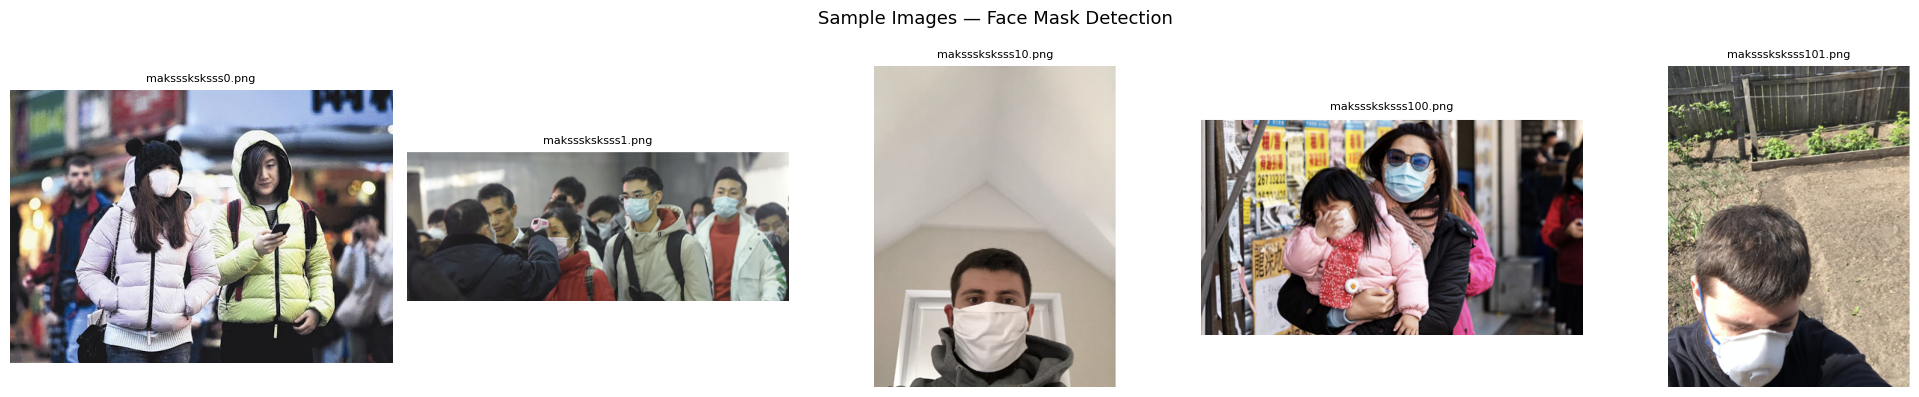

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

image_files = sorted(os.listdir(INPUT_IMAGES))[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, fname in zip(axes, image_files):
    img = Image.open(os.path.join(INPUT_IMAGES, fname))
    ax.imshow(img)
    ax.set_title(fname, fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Images — Face Mask Detection', fontsize=13)
plt.tight_layout()
plt.show()

## Задание 2. Датасет PyTorch для Faster R-CNN


In [ ]:
import torch
import xml.etree.ElementTree as ET
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader

CLASS_DICT = {'with_mask': 1, 'mask_weared_incorrect': 2, 'without_mask': 3}

class FaceMaskDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, file_list):
        self.image_dir      = image_dir
        self.annotation_dir = annotation_dir
        self.file_list      = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname    = self.file_list[idx]
        img_path = os.path.join(self.image_dir, fname)
        xml_path = os.path.join(self.annotation_dir, fname.replace('.png', '.xml'))

        img = Image.open(img_path).convert('RGB')
        img_tensor = TF.to_tensor(img)

        boxes, labels = [], []
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            for obj in root.findall('object'):
                name = obj.find('name').text
                if name not in CLASS_DICT:
                    continue
                bndbox = obj.find('bndbox')
                xmin = float(bndbox.find('xmin').text)
                ymin = float(bndbox.find('ymin').text)
                xmax = float(bndbox.find('xmax').text)
                ymax = float(bndbox.find('ymax').text)
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(CLASS_DICT[name])

        target = {
            'boxes':    torch.tensor(boxes,  dtype=torch.float32),
            'labels':   torch.tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([idx]),
        }
        return img_tensor, target


def collate_fn(batch):
    """Faster R-CNN требует список изображений и список таргетов, а не стек тензоров."""
    images  = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets


print('Dataset class defined.')

Dataset class defined.


In [ ]:
from sklearn.model_selection import train_test_split

all_images = sorted([f for f in os.listdir(INPUT_IMAGES) if f.endswith('.png')])
train_files, val_files = train_test_split(all_images, test_size=0.2, random_state=42)

train_dataset = FaceMaskDataset(INPUT_IMAGES, INPUT_ANNOTATIONS, train_files)
val_dataset   = FaceMaskDataset(INPUT_IMAGES, INPUT_ANNOTATIONS, val_files)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False, collate_fn=collate_fn)

print(f'Train: {len(train_dataset)} images  |  Val: {len(val_dataset)} images')

imgs, tgts = next(iter(train_loader))
print(f'Batch images: {len(imgs)}, image shape: {imgs[0].shape}')
print(f'Target keys: {list(tgts[0].keys())}')
print(f'Boxes shape: {tgts[0]["boxes"].shape}')
print(f'Labels: {tgts[0]["labels"]}')

Train: 682 images  |  Val: 171 images
Batch images: 4, image shape: torch.Size([3, 399, 600])
Target keys: ['boxes', 'labels', 'image_id']
Boxes shape: torch.Size([1, 4])
Labels: tensor([2])


## Задание 3. Инициализация Faster R-CNN


In [ ]:
import torchvision
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

NUM_CLASSES = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

model = model.to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всего параметров    : {total_params:,}')
print(f'Обучаемых параметров: {trainable_params:,}')

Device: cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 175MB/s]


Всего параметров    : 41,309,411
Обучаемых параметров: 41,087,011


## Задание 4. Обучение модели


Epoch 1/10: 100%|██████████| 171/171 [04:41<00:00,  1.64s/it]


Epoch  1/10 | Loss: 0.4323


Epoch 2/10: 100%|██████████| 171/171 [04:49<00:00,  1.69s/it]


Epoch  2/10 | Loss: 0.2800


Epoch 3/10: 100%|██████████| 171/171 [04:51<00:00,  1.71s/it]


...

Epoch  8/10 | Loss: 0.1252


Epoch 9/10: 100%|██████████| 171/171 [04:52<00:00,  1.71s/it]


Epoch  9/10 | Loss: 0.1208


Epoch 10/10: 100%|██████████| 171/171 [04:47<00:00,  1.68s/it]

Epoch 10/10 | Loss: 0.1156


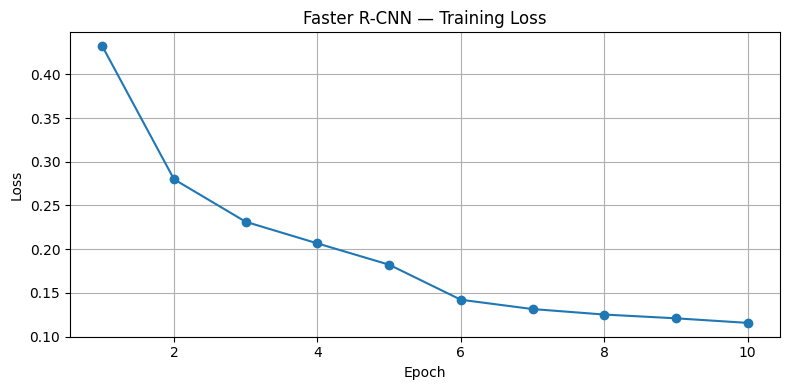

In [ ]:
from torch.optim import SGD
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm

EPOCHS = 10

optimizer = SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=0.0005
)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for images, targets in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}'):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += losses.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o')
plt.title('Faster R-CNN — Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True)
plt.tight_layout()
plt.show()

## Задание 5. Инференс и визуализация предсказаний


In [ ]:
import math
import numpy as np

CLASS_NAMES  = {0: 'background', 1: 'with_mask', 2: 'mask_incorrect', 3: 'without_mask'}
CLASS_COLORS = {0: 'gray', 1: 'green', 2: 'orange', 3: 'red'}
CONF_THRESH  = 0.5

model.eval()

sample_files = val_files[:9]

cols = 3
rows = math.ceil(len(sample_files) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

for i, fname in enumerate(sample_files):
    img_path = os.path.join(INPUT_IMAGES, fname)
    img_pil  = Image.open(img_path).convert('RGB')
    img_tensor = TF.to_tensor(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        preds = model(img_tensor)[0]

    ax = axes[i]
    ax.imshow(img_pil)

    for box, label, score in zip(
            preds['boxes'].cpu(), preds['labels'].cpu(), preds['scores'].cpu()):
        if score < CONF_THRESH:
            continue
        x1, y1, x2, y2 = box.tolist()
        color = CLASS_COLORS.get(label.item(), 'blue')
        rect  = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"{CLASS_NAMES[label.item()]} {score:.2f}",
                color='white', fontsize=7, backgroundcolor=color)

    ax.set_title(fname, fontsize=7)
    ax.axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Faster R-CNN — Val Predictions (conf ≥ 0.5)', fontsize=13)
plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

## Задание 6. Оценка — IoU и mAP


In [ ]:
from torchvision.ops import box_iou

def compute_ap(recalls, precisions):
    """AP через 11-точечную интерполяцию (PASCAL VOC стиль)."""
    ap = 0.0
    for t in [r / 10 for r in range(11)]:
        prec = [p for r, p in zip(recalls, precisions) if r >= t]
        ap  += max(prec) if prec else 0.0
    return ap / 11


def evaluate_map(model, loader, num_classes=4, iou_thresh=0.5, conf_thresh=0.01):
    model.eval()
    all_preds = {c: [] for c in range(1, num_classes)}
    gt_counts = {c: 0  for c in range(1, num_classes)}

    with torch.no_grad():
        for images, targets in tqdm(loader, desc='Evaluating'):
            images = [img.to(device) for img in images]
            preds  = model(images)

            for pred, target in zip(preds, targets):
                gt_boxes  = target['boxes'].to(device)
                gt_labels = target['labels']

                for c in range(1, num_classes):
                    gt_mask = (gt_labels == c)
                    gt_c    = gt_boxes[gt_mask]
                    gt_counts[c] += gt_c.shape[0]

                    pred_mask   = pred['labels'] == c
                    pred_boxes  = pred['boxes'][pred_mask]
                    pred_scores = pred['scores'][pred_mask]

                    matched_gt = set()
                    for box, score in zip(pred_boxes, pred_scores):
                        if score < conf_thresh:
                            continue
                        if gt_c.shape[0] > 0:
                            ious = box_iou(box.unsqueeze(0), gt_c)[0]
                            best_iou, best_j = ious.max(0)
                            if best_iou >= iou_thresh and best_j.item() not in matched_gt:
                                matched_gt.add(best_j.item())
                                all_preds[c].append((score.item(), 1))
                            else:
                                all_preds[c].append((score.item(), 0))
                        else:
                            all_preds[c].append((score.item(), 0))

    class_names_map = {1: 'with_mask', 2: 'mask_incorrect', 3: 'without_mask'}
    ap_per_class = {}
    for c in range(1, num_classes):
        preds_c = sorted(all_preds[c], key=lambda x: x[0], reverse=True)
        if not preds_c or gt_counts[c] == 0:
            ap_per_class[c] = 0.0
            continue
        tp_cumsum = 0
        fp_cumsum = 0
        precisions, recalls = [], []
        for score, tp in preds_c:
            tp_cumsum += tp
            fp_cumsum += (1 - tp)
            precisions.append(tp_cumsum / (tp_cumsum + fp_cumsum))
            recalls.append(tp_cumsum / gt_counts[c])
        ap_per_class[c] = compute_ap(recalls, precisions)
        print(f'  AP@0.5 [{class_names_map[c]:>20}]: {ap_per_class[c]:.4f}')

    mAP = sum(ap_per_class.values()) / len(ap_per_class)
    print(f'\n  mAP@0.5: {mAP:.4f}')
    return ap_per_class, mAP


print('=== Оценка на val выборке ===')
ap_per_class, mAP = evaluate_map(model, val_loader)

=== Оценка на val выборке ===


Evaluating: 100%|██████████| 86/86 [00:30<00:00,  2.86it/s]

  AP@0.5 [           with_mask]: 0.8986
  AP@0.5 [      mask_incorrect]: 0.4987
  AP@0.5 [        without_mask]: 0.8611

  mAP@0.5: 0.7528


## Задание 7. Анализ порога уверенности


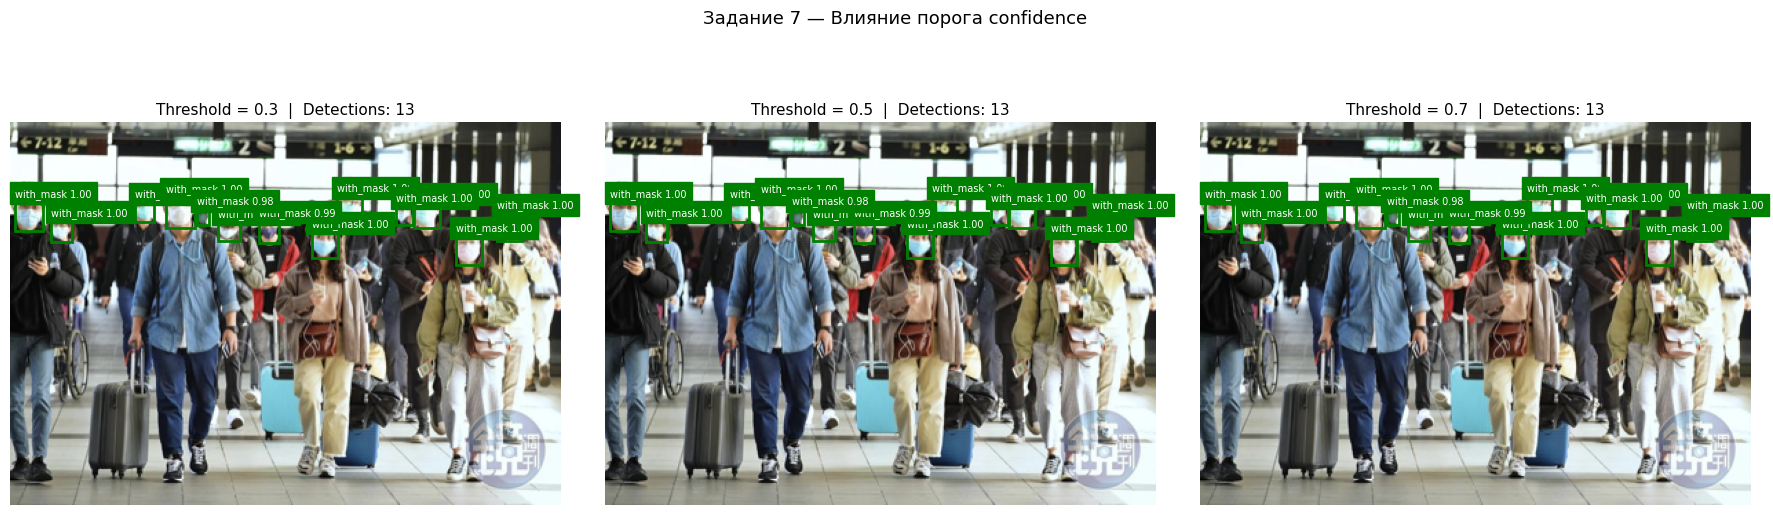

In [ ]:
THRESHOLDS = [0.3, 0.5, 0.7]
test_img_path = os.path.join(INPUT_IMAGES, val_files[0])
img_pil = Image.open(test_img_path).convert('RGB')
img_tensor = TF.to_tensor(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(img_tensor)[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, thresh in zip(axes, THRESHOLDS):
    ax.imshow(img_pil)
    count = 0
    for box, label, score in zip(pred['boxes'].cpu(), pred['labels'].cpu(), pred['scores'].cpu()):
        if score < thresh:
            continue
        count += 1
        x1, y1, x2, y2 = box.tolist()
        color = CLASS_COLORS.get(label.item(), 'blue')
        rect = plt.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-4, f"{CLASS_NAMES[label.item()]} {score:.2f}",
                color='white', fontsize=7, backgroundcolor=color)
    ax.set_title(f'Threshold = {thresh}  |  Detections: {count}', fontsize=11)
    ax.axis('off')

plt.suptitle('Задание 7 — Влияние порога confidence', fontsize=13)
plt.tight_layout()
plt.show()

## Задание 8. Gradio-приложение — локальная загрузка .pth и инференс

In [2]:
!pip install -q gradio

In [3]:
import gradio as gr
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as TF
from PIL import Image, ImageDraw, ImageFont

NUM_CLASSES  = 4
CLASS_NAMES  = {0: 'background', 1: 'with_mask', 2: 'mask_incorrect', 3: 'without_mask'}
CLASS_COLORS = {0: '#888888',    1: '#2ED573',    2: '#FFA502',         3: '#FF4757'}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Устройство:", DEVICE)

_model_cache = {"model": None, "path": None}


def load_model(weights_path: str):
    """Загружает и кэширует модель из .pth файла."""
    if _model_cache["path"] == weights_path and _model_cache["model"] is not None:
        return _model_cache["model"]

    model = fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

    state = torch.load(weights_path, map_location=DEVICE)
    if isinstance(state, dict) and "model" in state:
        state = state["model"]
    model.load_state_dict(state)
    model.to(DEVICE).eval()

    _model_cache["model"] = model
    _model_cache["path"]  = weights_path
    return model


def run_inference(
    pth_file,
    pil_image,
    score_threshold,
    show_labels,
    show_scores,
    line_width,
):
    if pth_file is None:
        return None, "⚠️ Сначала загрузите .pth файл!"
    if pil_image is None:
        return None, "⚠️ Загрузите изображение!"

    try:
        model = load_model(pth_file)
    except Exception as e:
        return None, f"❌ Ошибка загрузки модели:\n```\n{e}\n```"

    img = pil_image.convert("RGB")
    tensor = TF.to_tensor(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(tensor)[0]

    mask   = output["scores"] >= score_threshold
    boxes  = output["boxes"] [mask].cpu()
    labels = output["labels"][mask].cpu()
    scores = output["scores"][mask].cpu()

    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 14)
    except Exception:
        font = ImageFont.load_default()

    for box, lbl, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.tolist()
        lbl_idx = int(lbl)
        color = CLASS_COLORS.get(lbl_idx, "#1E90FF")

        draw.rectangle([x1, y1, x2, y2], outline=color, width=int(line_width))

        parts = []
        if show_labels:
            parts.append(CLASS_NAMES.get(lbl_idx, str(lbl_idx)))
        if show_scores:
            parts.append(f"{score:.2f}")

        if parts:
            text = " ".join(parts)
            try:
                tb = draw.textbbox((x1, y1 - 18), text, font=font)
                draw.rectangle(tb, fill=color)
                draw.text((x1, y1 - 18), text, fill="white", font=font)
            except Exception:
                draw.text((x1, y1 - 18), text, fill=color)

    n = len(boxes)
    lines = [f"✅ Найдено объектов: **{n}**\n"]
    counts = {}
    for lbl in labels:
        name = CLASS_NAMES.get(int(lbl), str(int(lbl)))
        counts[name] = counts.get(name, 0) + 1
    for name, cnt in counts.items():
        color_map = {"with_mask": "🟢", "mask_incorrect": "🟠", "without_mask": "🔴"}
        icon = color_map.get(name, "⚪")
        lines.append(f"{icon} **{name}**: {cnt}")

    if n == 0:
        lines = ["Объектов не найдено. Попробуйте снизить порог."]

    return img, "\n".join(lines)


with gr.Blocks(
    title="Face Mask Detection — Faster R-CNN",
    theme=gr.themes.Soft(primary_hue="emerald", neutral_hue="slate"),
) as demo:

    gr.Markdown("""
    # 😷 Face Mask Detection — Faster R-CNN
    **Шаг 1:** Загрузите ваш `.pth` файл (сохранённый в Google Colab)
    **Шаг 2:** Загрузите изображение
    **Шаг 3:** Нажмите **Detect**
    """)

    with gr.Row():
        with gr.Column(scale=1):
            pth_upload = gr.File(
                label="📦 Загрузите .pth файл",
                file_types=[".pth"],
                type="filepath",
            )
            inp_image = gr.Image(
                type="pil",
                label="🖼️ Изображение",
                height=320,
            )

            with gr.Accordion("⚙️ Настройки", open=True):
                score_thr  = gr.Slider(0.05, 0.99, value=0.5, step=0.05,
                                       label="Порог уверенности")
                line_width = gr.Slider(1, 8, value=3, step=1,
                                       label="Толщина рамки")
                with gr.Row():
                    show_labels = gr.Checkbox(value=True, label="Класс")
                    show_scores = gr.Checkbox(value=True, label="Score")

            detect_btn = gr.Button("🔍 Detect", variant="primary", size="lg")

        with gr.Column(scale=1):
            out_image = gr.Image(type="pil", label="Результат", height=320,
                                 interactive=False)
            out_stats = gr.Markdown()

    gr.Markdown("""
    ---
    **Классы:** 🟢 `with_mask` &nbsp;|&nbsp; 🟠 `mask_incorrect` &nbsp;|&nbsp; 🔴 `without_mask`
    """)

    detect_btn.click(
        fn=run_inference,
        inputs=[pth_upload, inp_image, score_thr, show_labels, show_scores, line_width],
        outputs=[out_image, out_stats],
    )

demo.launch(share=True)

Устройство: cuda


/tmp/ipykernel_2331/2857844067.py:119: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a2d5bece9c1545f20.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
